1.- Con las imágenes contenidas en la carpeta procésalas de manera que obtengan el siguiente resultado

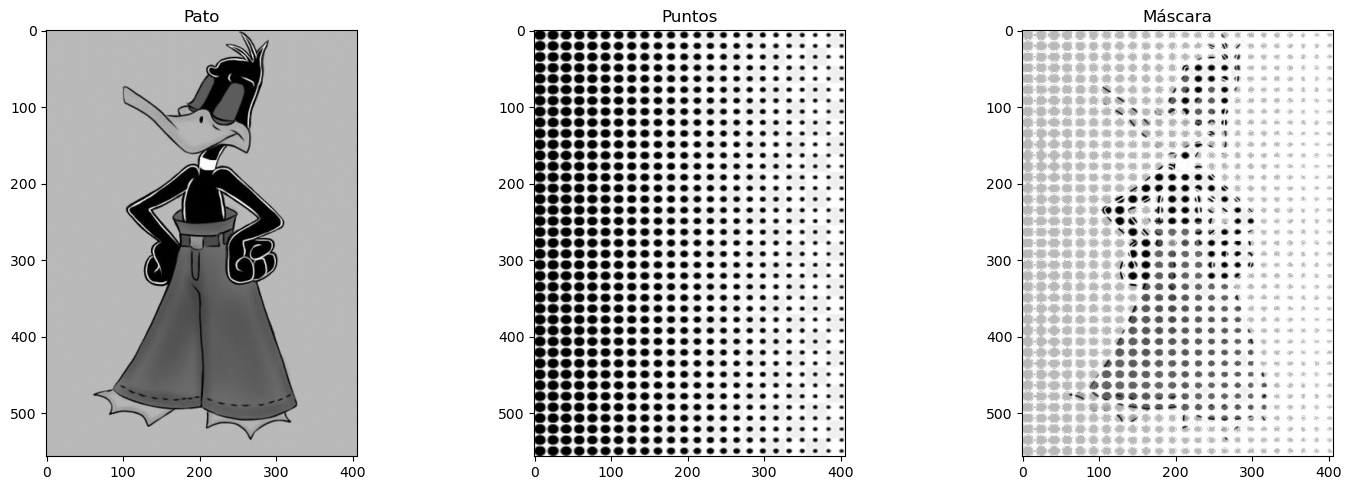

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_pato = cv2.imread('pato.jpg')
img_puntos = cv2.imread('puntos.png', cv2.IMREAD_GRAYSCALE)
pato_gris = cv2.cvtColor(img_pato, cv2.COLOR_BGR2GRAY)
puntos_resized = cv2.resize(img_puntos, (pato_gris.shape[1], pato_gris.shape[0]))
mascara = cv2.bitwise_not(puntos_resized)
blanco = np.ones_like(pato_gris) * 255
fusion = cv2.bitwise_and(pato_gris, mascara)
fusion = cv2.add(fusion, cv2.bitwise_and(blanco, cv2.bitwise_not(mascara)))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Pato")
plt.imshow(pato_gris, cmap='gray')

plt.subplot(1,3,2)
plt.title("Puntos")
plt.imshow(puntos_resized, cmap='gray')

plt.subplot(1,3,3)
plt.title("Máscara")
plt.imshow(fusion, cmap='gray')

plt.tight_layout()
plt.show()


2.- Cuenta cuantos objetos de cada color se encuentran en la imagen

detección de colores con HSV

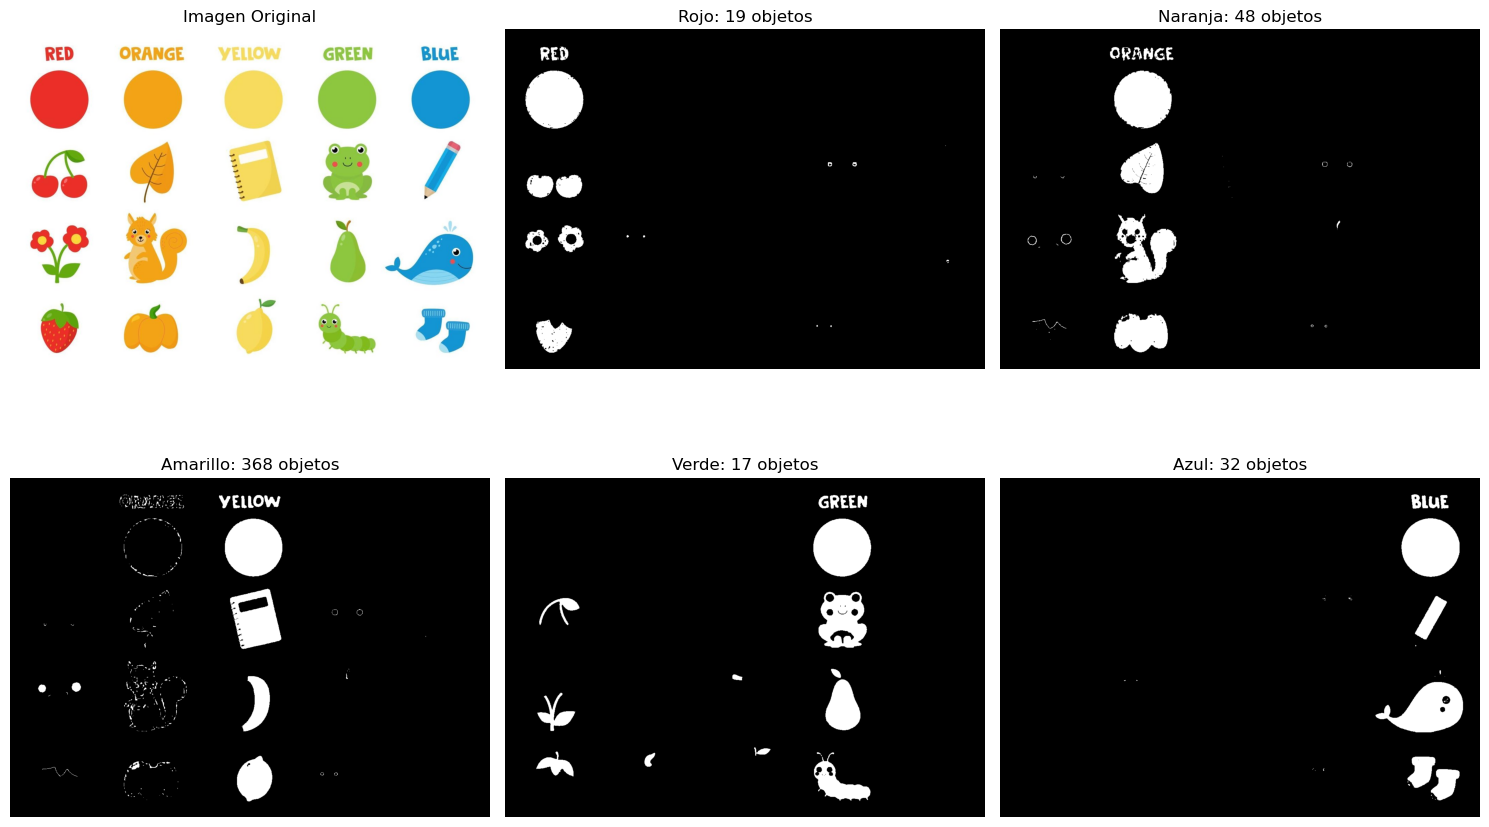

In [32]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

rangos = {
    "Rojo": [(0, 120, 70), (10, 255, 255)],
    "Naranja": [(11, 150, 150), (20, 255, 255)],  
    "Amarillo": [(21, 100, 100), (30, 255, 255)], 
    "Verde": [(36, 100, 100), (86, 255, 255)],
    "Azul": [(94, 80, 2), (126, 255, 255)],
}

def conteo(img, bajo, alto):
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mascara = cv2.inRange(img_hsv, np.array(bajo), np.array(alto))
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return len(contornos), mascara

imagen = cv2.imread('colores.jpg')

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis('off')

cantidad_rojo, mascara_rojo = conteo(imagen, *rangos["Rojo"])
plt.subplot(2, 3, 2)
plt.imshow(mascara_rojo, cmap='gray')
plt.title(f"Rojo: {cantidad_rojo} objetos")
plt.axis('off')

cantidad_naranja, mascara_naranja = conteo(imagen, *rangos["Naranja"])
plt.subplot(2, 3, 3)
plt.imshow(mascara_naranja, cmap='gray')
plt.title(f"Naranja: {cantidad_naranja} objetos")
plt.axis('off')

cantidad_amarillo, mascara_amarillo = conteo(imagen, *rangos["Amarillo"])
plt.subplot(2, 3, 4)
plt.imshow(mascara_amarillo, cmap='gray')
plt.title(f"Amarillo: {cantidad_amarillo} objetos")
plt.axis('off')

cantidad_verde, mascara_verde = conteo(imagen, *rangos["Verde"])
plt.subplot(2, 3, 5)
plt.imshow(mascara_verde, cmap='gray')
plt.title(f"Verde: {cantidad_verde} objetos")
plt.axis('off')

cantidad_azul, mascara_azul = conteo(imagen, *rangos["Azul"])
plt.subplot(2, 3, 6)
plt.imshow(mascara_azul, cmap='gray')
plt.title(f"Azul: {cantidad_azul} objetos")
plt.axis('off')

plt.tight_layout()
plt.show()


detección de colores con RGB

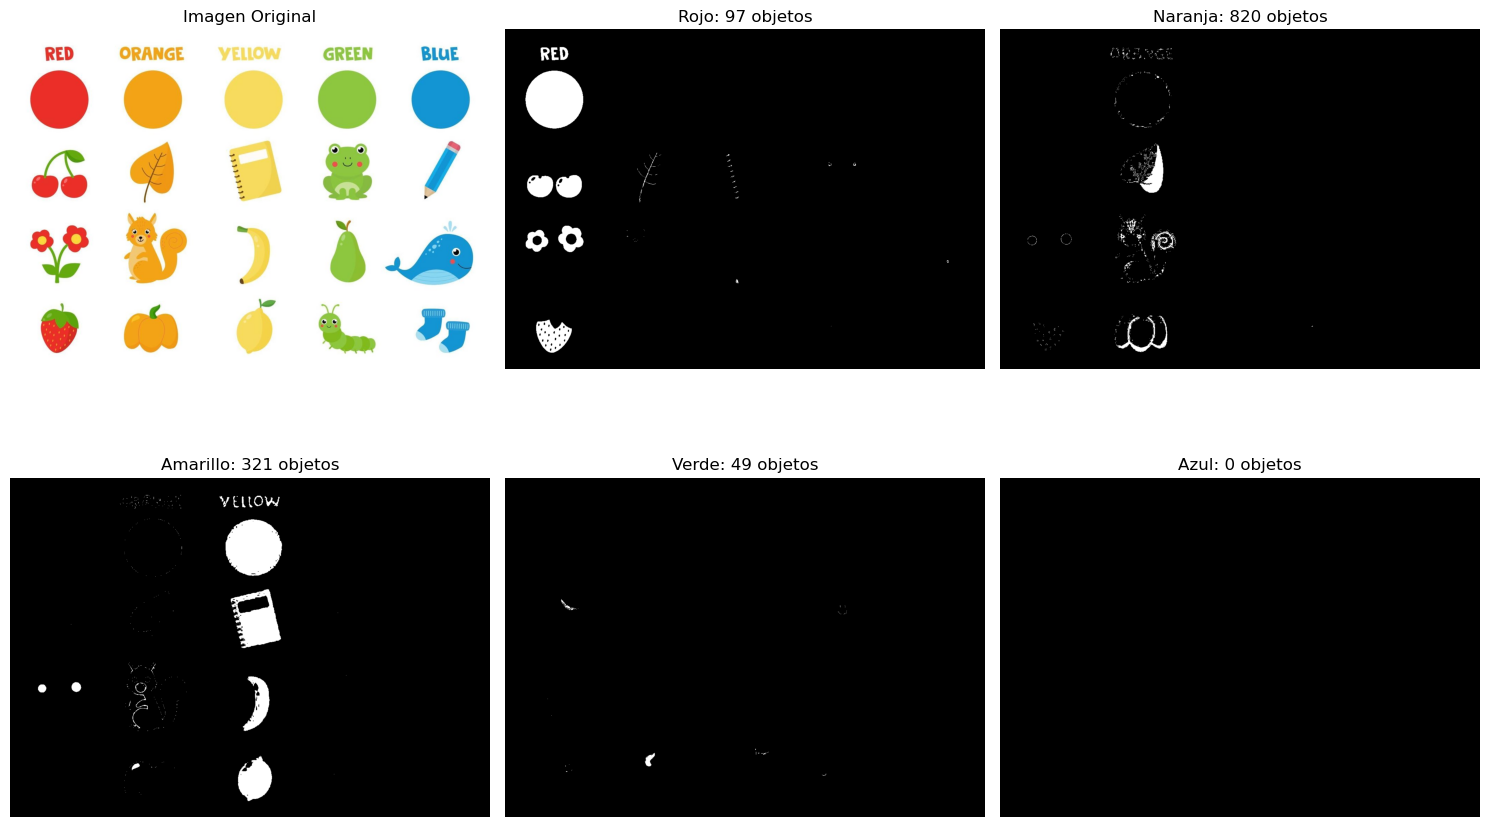

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

rangos_rgb = {
    "Rojo": [(100, 0, 0), (255, 80, 80)],      
    "Naranja": [(200, 80, 0), (255, 160, 50)],  
    "Amarillo": [(180, 180, 0), (255, 255, 100)],
    "Verde": [(0, 100, 0), (80, 255, 80)],   
    "Azul": [(0, 0, 150), (100, 100, 255)],    
}


def conteo_rgb(img, bajo, alto):
    mascara = cv2.inRange(img, np.array(bajo, dtype=np.uint8), np.array(alto, dtype=np.uint8))
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return len(contornos), mascara

imagen = cv2.imread('colores.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(imagen_rgb)
plt.title("Imagen Original")
plt.axis('off')

cantidad_rojo, mascara_rojo = conteo_rgb(imagen_rgb, *rangos_rgb["Rojo"])
plt.subplot(2, 3, 2)
plt.imshow(mascara_rojo, cmap='gray')
plt.title(f"Rojo: {cantidad_rojo} objetos")
plt.axis('off')

cantidad_naranja, mascara_naranja = conteo_rgb(imagen_rgb, *rangos_rgb["Naranja"])
plt.subplot(2, 3, 3)
plt.imshow(mascara_naranja, cmap='gray')
plt.title(f"Naranja: {cantidad_naranja} objetos")
plt.axis('off')

cantidad_amarillo, mascara_amarillo = conteo_rgb(imagen_rgb, *rangos_rgb["Amarillo"])
plt.subplot(2, 3, 4)
plt.imshow(mascara_amarillo, cmap='gray')
plt.title(f"Amarillo: {cantidad_amarillo} objetos")
plt.axis('off')

cantidad_verde, mascara_verde = conteo_rgb(imagen_rgb, *rangos_rgb["Verde"])
plt.subplot(2, 3, 5)
plt.imshow(mascara_verde, cmap='gray')
plt.title(f"Verde: {cantidad_verde} objetos")
plt.axis('off')

cantidad_azul, mascara_azul = conteo_rgb(imagen_rgb, *rangos_rgb["Azul"])
plt.subplot(2, 3, 6)
plt.imshow(mascara_azul, cmap='gray')
plt.title(f"Azul: {cantidad_azul} objetos")
plt.axis('off')

plt.tight_layout()
plt.show()


3.- Estás trabajando en un proyecto de reconocimiento de rostros y necesitas detectar los bordes de las caras en las imágenes. Explique cómo aplicaría el operador de detección de bordes de Canny y aplícalo con un código en Python en jupyte

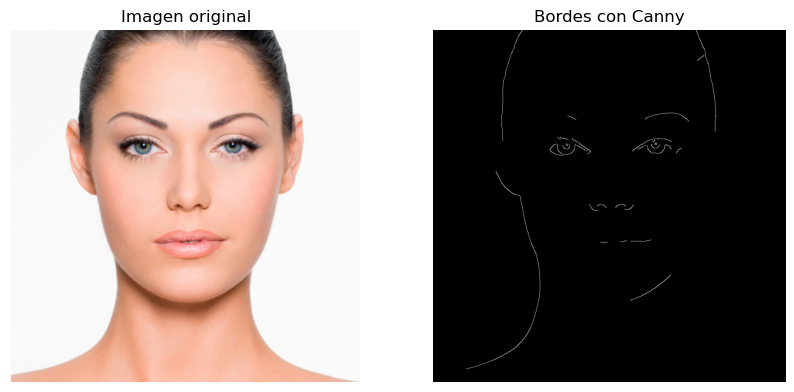

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = cv2.imread('rostro.jpg')  
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(img_gray, (5, 5), 1.4)
bordes_canny = cv2.Canny(blur, 100, 200)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Canny")
plt.imshow(bordes_canny, cmap='gray')
plt.show()


codigo de la página web 
https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

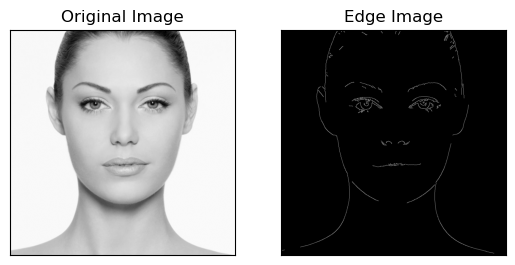

In [25]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
img = cv.imread('rostro.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
edges = cv.Canny(img,100,200)
 
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
 
plt.show()

El detector Candy fue desarrollado por John F. Canny, es un algoritmo de varias etapas, reduce el ruido y encuentra el gradiente de intensidad de la imagen. Cuando se obtiene la magnitud y la dirección del gradiente se puede realizar un escaneo completo, elimina los píxeles que no contribuyen al borde. 